**MIPACE Feature Extraction**

In [49]:
import pandas as pd
import numpy as np
import os 
import glob
import matplotlib.pyplot as plt

In [36]:
path = r'visit_data'

# Use glob to get all CSV files in the path
filenames = glob.glob(os.path.join(path, "*.csv"))

# Initialize an empty dictionary to store dataframes
dfs = {}

# Loop through each CSV file and read it into a dataframe
for filename in filenames:
    # Extract the filename without the directory and extension
    file_key = os.path.splitext(os.path.basename(filename))[0]
    # Remove '_visit_data' from the filename
    file_key = file_key.replace("_MiPACE_visit_data", "")
    # Read the CSV file into a dataframe
    dfs[file_key] = pd.read_csv(filename)


In [11]:
dfs['TR000100_20220203']

,participant_ID,visit_date,visit_type,t,Rf,VT,VE,IV,VO2,VCO2,...,mark Distance,Phase time,VO2/Kg%Pred,BR,VT/Ti,HRR,PaCO2_e,Dyspnea,SV e,CO e
0,TR000100,20220203,MiPACE,00:00:01,23.72,0.823,19.518,509,832.406802,648.519895,...,0,00:00,45,83.5,0.50,129,39,NaN,178.3,9.6
1,TR000100,20220203,MiPACE,00:00:06,11.45,0.851,9.744,825,425.775504,327.672780,...,0,00:05,23,91.8,0.33,129,39,NaN,109.3,5.9
2,TR000100,20220203,MiPACE,00:00:16,6.22,2.646,16.469,2497,546.955374,487.103978,...,0,00:15,30,86.1,0.76,119,36,NaN,111.8,7.2
3,TR000100,20220203,MiPACE,00:00:20,14.08,0.467,6.577,562,243.244898,195.835698,...,0,00:19,13,94.4,0.21,119,37,NaN,57.8,3.7
4,TR000100,20220203,MiPACE,00:00:23,20.62,0.721,14.866,395,573.933809,453.883859,...,0,00:22,31,87.4,0.79,121,38,NaN,119.6,7.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1165,TR000100,20220203,MiPACE,00:44:47,12.96,0.632,8.190,760,286.486666,229.591541,...,0,19:53,16,93.1,0.36,91,35,LEVEL_20,46.3,4.3
1166,TR000100,20220203,MiPACE,00:44:51,15.35,0.602,9.238,492,313.671658,247.505503,...,0,19:57,17,92.2,0.52,92,36,LEVEL_20,50.5,4.6
1167,TR000100,20220203,MiPACE,00:44:55,16.67,0.544,9.067,573,263.759136,215.142208,...,0,20:01,14,92.3,0.45,92,34,LEVEL_20,43.6,4.0
1168,TR000100,20220203,MiPACE,00:44:56,31.91,0.309,9.862,346,194.470917,147.239391,...,0,20:02,11,91.7,0.37,92,28,LEVEL_20,33.4,3.0


In [37]:
path = r'visit_data'
filenames = glob.glob(path + "/*.csv")

df_list = []
for filename in filenames:
    df_list.append(pd.read_csv(filename))

# Concatenate all data into one DataFrame
big_frame = pd.concat(df_list, ignore_index=True)

#Add stage number
def stage_number(visit_df):
    visit_df['Stage'] = visit_df[visit_df['Phase'] == 'EXERCISE'].groupby(['Speed','Grade']).ngroup() + 1
    return visit_df

big_frame = big_frame.groupby(['participant_ID', 'visit_date']).apply(stage_number, include_groups=False).reset_index()

#Convert t to datetime
big_frame['t'] = pd.to_datetime('1900-01-01 ' + big_frame['t'], format='%Y-%m-%d %H:%M:%S') ## use dummy date for day





In [13]:
big_frame.head()

,participant_ID,visit_date,level_2,visit_type,t,Rf,VT,VE,IV,VO2,...,Phase time,VO2/Kg%Pred,BR,VT/Ti,HRR,PaCO2_e,Dyspnea,SV e,CO e,Stage
0,TR000100,20220203,352351,MiPACE,1900-01-01 00:00:01,23.72,0.823,19.518,509.0,832.406802,...,00:00,45.0,83.5,0.5,129.0,39.0,NaN,178.3,9.6,NaN
1,TR000100,20220203,352352,MiPACE,1900-01-01 00:00:06,11.45,0.851,9.744,825.0,425.775504,...,00:05,23.0,91.8,0.33,129.0,39.0,NaN,109.3,5.9,NaN
2,TR000100,20220203,352353,MiPACE,1900-01-01 00:00:16,6.22,2.646,16.469,2497.0,546.955374,...,00:15,30.0,86.1,0.76,119.0,36.0,NaN,111.8,7.2,NaN
3,TR000100,20220203,352354,MiPACE,1900-01-01 00:00:20,14.08,0.467,6.577,562.0,243.244898,...,00:19,13.0,94.4,0.21,119.0,37.0,NaN,57.8,3.7,NaN
4,TR000100,20220203,352355,MiPACE,1900-01-01 00:00:23,20.62,0.721,14.866,395.0,573.933809,...,00:22,31.0,87.4,0.79,121.0,38.0,NaN,119.6,7.4,NaN


In [38]:
#Split Up Dataframes
def create_dataframe_dictionary(parent_df):
    participant_registry = dict()
    for row in parent_df.itertuples():
        participant_registry[row.participant_ID] = dict()
    for row in parent_df.itertuples():
        participant_registry[row.participant_ID][row.visit_date] = []
    for row in parent_df.itertuples():
        participant_registry[row.participant_ID][row.visit_date].append(row)
    participant_df = dict()
    for participant_id, participant_data in participant_registry.items():
        for visit_date in participant_data.keys():
            participant_df[f'{participant_id}_{visit_date}'] = pd.DataFrame(participant_registry[participant_id][visit_date])
    print(participant_df.keys())
    return participant_df

participant_df = create_dataframe_dictionary(big_frame)
participant_df['TR000105_20220207'].columns



dict_keys(['TR000100_20220203', 'TR000100_20220331', 'TR000100_20220623', 'TR000101_20220203', 'TR000101_20220331', 'TR000101_20220630', 'TR000102_20220204', 'TR000102_20220401', 'TR000102_20220630', 'TR000103_20220204', 'TR000103_20220401', 'TR000103_20220706', 'TR000104_20220207', 'TR000104_20220314', 'TR000104_20220627', 'TR000105_20220207', 'TR000105_20220517', 'TR000105_20220920', 'TR000106_20220208', 'TR000106_20220420', 'TR000106_20220823', 'TR000107_20220208', 'TR000107_20220519', 'TR000107_20220805', 'TR000108_20220209', 'TR000109_20220209', 'TR000109_20220518', 'TR000109_20220824', 'TR000110_20220210', 'TR000110_20220428', 'TR000110_20220901', 'TR000111_20220210', 'TR000111_20220510', 'TR000111_20220901', 'TR000112_20220211', 'TR000112_20220602', 'TR000112_20221027', 'TR000113_20220211', 'TR000113_20220513', 'TR000113_20220909', 'TR000114_20220211', 'TR000114_20220519', 'TR000114_20220902', 'TR000115_20220211', 'TR000115_20220425', 'TR000115_20220912', 'TR000116_20220214', 'T

Index(['Index', 'participant_ID', 'visit_date', 'level_2', 'visit_type', 't',
       'Rf', 'VT', 'VE', 'IV', 'VO2', 'VCO2', 'RQ', 'O2exp', 'CO2exp', '_15',
       '_16', '_17', 'METS', 'HR', '_20', 'FeO2', 'FeCO2', 'FetO2', 'FetCO2',
       'FiO2', 'FiCO2', 'PeO2', 'PeCO2', 'PetO2', 'PetCO2', 'SpO2', 'Grade',
       'Speed', 'Phase', 'Marker', '_36', '_37', '_38', 'PB', 'EEkc', 'EEh',
       'EEm', 'EEtot', 'EEkg', 'PRO', 'Fat', 'CHO', '_48', '_49', '_50',
       'npRQ', '_52', '_53', '_54', '_55', '_56', '_57', '_58', '_59', '_60',
       '_61', '_62', '_63', '_64', '_65', '_66', '_67', '_68', '_69', '_70',
       '_71', '_72', '_73', '_74', '_75', '_76', '_77', 'Ti', 'Te', 'Ttot',
       '_81', '_82', 'LogVE', '_84', '_85', '_86', '_87', '_88', 'BR', '_90',
       'HRR', 'PaCO2_e', 'Dyspnea', '_94', '_95', 'Stage'],
      dtype='object')

In [15]:
def test_keys(df_dictionary):
    for key, values in df_dictionary.items():
        for row in values.itertuples():
            assert key == f'{row.participant_ID}_{row.visit_date}'
    return True

test_keys(participant_df)

True

In [39]:
#Create VO2 Outcome DF
def create_outcome_df(dictionary_df):
    id_list = list(dictionary_df.keys())
    result_df = pd.DataFrame({
    "participant_visit_id": id_list,
    "VO2_peak": None,
    "VO2/kgPeak": None,
    "True VO2max": None,
    #"VO2Peak start time- global": None,
    #"VO2Peak end time- global": None,
    "VO2Peak start time- local": None,
    "VO2Peak end time- local": None,
    "RQPeak": None,
    "HRPeak": None,
    "GradePeak": None,
    "SpeedPeak": None,
    "MarkerPeak": None,
    "EEMPeak": None,
    "Fat%Peak": None,
    "CHO%Peak": None,
    "Lactate-VO2Peak": None,
    "RPE-VO2peak": None,
    })

    # Set participant_id as the index
    result_df.set_index("participant_visit_id", inplace=True)
    return result_df
create_outcome_df(participant_df)
VO2_outcome_df = create_outcome_df(participant_df)
VO2_outcome_df

,VO2_peak,VO2/kgPeak,True VO2max,VO2Peak start time- local,VO2Peak end time- local,RQPeak,HRPeak,GradePeak,SpeedPeak,MarkerPeak,EEMPeak,Fat%Peak,CHO%Peak,Lactate-VO2Peak,RPE-VO2peak
participant_visit_id,,,,,,,,,,,,,,,
TR000100_20220203,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
TR000100_20220331,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
TR000100_20220623,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
TR000101_20220203,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
TR000101_20220331,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TR000315_20230224,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
TR000316_20220907,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
TR000316_20221101,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None


In [40]:
# Get Visit Number
VO2_outcome_df['ID'] = VO2_outcome_df.index.str.split('_').str[0]
VO2_outcome_df['Visit Date'] = VO2_outcome_df.index.str.split('_').str[1]
VO2_outcome_df = VO2_outcome_df.sort_values(by=['ID', 'Visit Date'])
VO2_outcome_df['Visit Number'] = VO2_outcome_df.groupby('ID').cumcount()+1

In [44]:

def get_VO2_peak_and_time(id, test_df, VO2_outcome_df):
    """
    Calculates the peak VO2 value over a 30-second rolling window and records 
    the start and end times of this peak period.

    Args:
        id (str): Unique identifier for the participant and visit.
        test_df (pd.DataFrame): DataFrame containing time-series VO2 data.
        VO2_outcome_df (pd.DataFrame): DataFrame to store VO2 peak results.

    Returns:
        None (Updates VO2_outcome_df in place).
    """

    # (Commented-out code for manually setting 'id' and converting time format)
    # id = f'{test_df['participant_ID'][0]}_{test_df['visit_date'][0]}'
    # test_df['t'] = pd.to_datetime('1900-01-01 ' + test_df['t'], format='%Y-%m-%d %H:%M:%S')

    # Compute a 30-second rolling average of VO2 values based on time column 't'
    rolling_avg = test_df.rolling('30s', on='t')['VO2'].mean()
    # Identify the maximum rolling average VO2 value
    max_avg = rolling_avg.max()
    # Find the index corresponding to the maximum rolling average (end of peak period)
    end_index = rolling_avg.idxmax()
    # Retrieve the timestamp corresponding to the end of the VO2 peak period
    end_time = test_df.loc[end_index, 't']
    # Find the start index of the 30-second peak window
    start_index = test_df.loc[test_df['t'] <= end_time - pd.Timedelta(seconds=30)].index[-1]
    # Retrieve the timestamp corresponding to the start of the VO2 peak period
    start_time = test_df.loc[start_index, 't']
    # Store the peak VO2 value and its corresponding start and end times in the output DataFrame
    VO2_outcome_df.loc[id, 'VO2_peak'] = max_avg
    VO2_outcome_df.loc[id, 'VO2Peak start time- local'] = start_time
    VO2_outcome_df.loc[id, 'VO2Peak end time- local'] = end_time
    return

# Iterate through each participant's data and compute their VO2 peak values
for id, df in participant_df.items():
    try:
        get_VO2_peak_and_time(id, df, VO2_outcome_df)
    except Exception as e:
        print(f"Error processing {id}: {e}")
        continue

# Display the first few rows of the results DataFrame
VO2_outcome_df

Error processing TR000263_20220608: t values must not have NaT


,VO2_peak,VO2/kgPeak,True VO2max,VO2Peak start time- local,VO2Peak end time- local,RQPeak,HRPeak,GradePeak,SpeedPeak,MarkerPeak,EEMPeak,Fat%Peak,CHO%Peak,Lactate-VO2Peak,RPE-VO2peak,ID,Visit Date,Visit Number
participant_visit_id,,,,,,,,,,,,,,,,,,
TR000100_20220203,3105.897672,None,None,1900-01-01 00:22:25,1900-01-01 00:22:55,None,None,None,None,None,None,None,None,None,None,TR000100,20220203,1
TR000100_20220331,3451.548659,None,None,1900-01-01 00:20:39,1900-01-01 00:21:09,None,None,None,None,None,None,None,None,None,None,TR000100,20220331,2
TR000100_20220623,3453.436232,None,None,1900-01-01 00:26:29,1900-01-01 00:26:59,None,None,None,None,None,None,None,None,None,None,TR000100,20220623,3
TR000101_20220203,2641.110769,None,None,1900-01-01 00:21:48,1900-01-01 00:22:19,None,None,None,None,None,None,None,None,None,None,TR000101,20220203,1
TR000101_20220331,2653.500411,None,None,1900-01-01 00:23:36,1900-01-01 00:24:06,None,None,None,None,None,None,None,None,None,None,TR000101,20220331,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TR000315_20230224,3489.329988,None,None,1900-01-01 00:15:19,1900-01-01 00:15:49,None,None,None,None,None,None,None,None,None,None,TR000315,20230224,3
TR000316_20220907,3921.098749,None,None,1900-01-01 00:28:43,1900-01-01 00:29:13,None,None,None,None,None,None,None,None,None,None,TR000316,20220907,1
TR000316_20221101,4127.676588,None,None,1900-01-01 00:32:50,1900-01-01 00:33:20,None,None,None,None,None,None,None,None,None,None,TR000316,20221101,2


In [46]:
VO2_outcome_df[VO2_outcome_df['ID']=='TR000263']

,VO2_peak,VO2/kgPeak,True VO2max,VO2Peak start time- local,VO2Peak end time- local,RQPeak,HRPeak,GradePeak,SpeedPeak,MarkerPeak,EEMPeak,Fat%Peak,CHO%Peak,Lactate-VO2Peak,RPE-VO2peak,ID,Visit Date,Visit Number
participant_visit_id,,,,,,,,,,,,,,,,,,
TR000263_20220608,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,TR000263,20220608,1
TR000263_20220831,3936.264608,None,None,1900-01-01 00:26:51,1900-01-01 00:27:21,None,None,None,None,None,None,None,None,None,None,TR000263,20220831,2
TR000263_20230116,3974.135295,None,None,1900-01-01 00:24:20,1900-01-01 00:24:50,None,None,None,None,None,None,None,None,None,None,TR000263,20230116,3


In [47]:
rq_threshold = 1.0
#Get Grade, Speed, Stage at Peak VO2 for each row of VO2_outcome_df
def get_metrics(row):
    if not row['VO2_peak']:
        return row
    start_time = row['VO2Peak start time- local']
    end_time = row['VO2Peak end time- local']
    id = row.name
    #Grade, Speed, Stage at end time VO2
    #If end time is during recovery, use start time values
    if np.isnan(participant_df[id].loc[participant_df[id]['t'] == end_time, 'Stage'].values[0]):
        row['GradePeak'] = participant_df[id].loc[participant_df[id]['t'] == start_time, 'Grade'].values[0]
        row['SpeedPeak'] = participant_df[id].loc[participant_df[id]['t'] == start_time, 'Speed'].values[0]
        row['MarkerPeak'] = participant_df[id].loc[participant_df[id]['t'] == start_time, 'Stage'].values[0]
    else:
        row['GradePeak'] = participant_df[id].loc[participant_df[id]['t'] == end_time, 'Grade'].values[0]
        row['SpeedPeak'] = participant_df[id].loc[participant_df[id]['t'] == end_time, 'Speed'].values[0]
        row['MarkerPeak'] = participant_df[id].loc[participant_df[id]['t'] == end_time, 'Stage'].values[0]
        
    
    #Average values over the peak VO2 time
    row['RQPeak'] = participant_df[id].loc[(participant_df[id]['t'] >= start_time) & (participant_df[id]['t'] <= end_time), 'RQ'].mean()
    row['HRPeak'] = participant_df[id].loc[(participant_df[id]['t'] >= start_time) & (participant_df[id]['t'] <= end_time), 'HR'].mean()
    row['EEMPeak'] = participant_df[id].loc[(participant_df[id]['t'] >= start_time) & (participant_df[id]['t'] <= end_time), 'EEm'].mean()
    row['Fat%Peak'] = participant_df[id].loc[(participant_df[id]['t'] >= start_time) & (participant_df[id]['t'] <= end_time), 'Fat'].mean()
    row['CHO%Peak'] = participant_df[id].loc[(participant_df[id]['t'] >= start_time) & (participant_df[id]['t'] <= end_time), 'CHO'].mean()
    row['VO2/kgPeak'] = participant_df[id].loc[(participant_df[id]['t'] >= start_time) & (participant_df[id]['t'] <= end_time), '_16'].mean()

    #First value after VO2 peak
    row['Lactate-VO2Peak'] = participant_df[id].loc[(participant_df[id]['t'] >= end_time), '_49'].values[0]
    row['RPE-VO2peak'] = participant_df[id].loc[(participant_df[id]['t'] >= end_time), 'Dyspnea'].values[0]

    #True Vo2max if RQ is above threshold
    row['True VO2max'] = row['RQPeak'] > rq_threshold
    
    return row


VO2_outcome_df = VO2_outcome_df.apply(get_metrics, axis=1)



In [48]:
VO2_outcome_df.head()

,VO2_peak,VO2/kgPeak,True VO2max,VO2Peak start time- local,VO2Peak end time- local,RQPeak,HRPeak,GradePeak,SpeedPeak,MarkerPeak,EEMPeak,Fat%Peak,CHO%Peak,Lactate-VO2Peak,RPE-VO2peak,ID,Visit Date,Visit Number
participant_visit_id,,,,,,,,,,,,,,,,,,
TR000100_20220203,3105.897672,31.021739,False,1900-01-01 00:22:25,1900-01-01 00:22:55,0.946957,189.434783,0.0,9.8,6.0,15.325652,4125.173913,17943.217391,9.2,LEVEL_18,TR000100,20220203,1
TR000100_20220331,3451.548659,30.276471,False,1900-01-01 00:20:39,1900-01-01 00:21:09,0.810588,185.823529,0.0,9.2,5.0,16.498235,15330.588235,8427.117647,63.3,LEVEL_15,TR000100,20220331,2
TR000100_20220623,3453.436232,34.430769,False,1900-01-01 00:26:29,1900-01-01 00:26:59,0.907308,182.192308,2.0,9.8,7.0,16.842308,7919.961538,16332.461538,40.7,LEVEL_17,TR000100,20220623,3
TR000101_20220203,2641.110769,30.172000,True,1900-01-01 00:21:48,1900-01-01 00:22:19,1.037200,147.000000,0.0,8.3,6.0,13.270400,1322.160000,17788.520000,0.0,LEVEL_15,TR000101,20220203,1
TR000101_20220331,2653.500411,34.950000,False,1900-01-01 00:23:36,1900-01-01 00:24:06,0.991538,147.730769,0.0,8.3,6.0,12.996154,1216.307692,17498.923077,0.0,LEVEL_15,TR000101,20220331,2


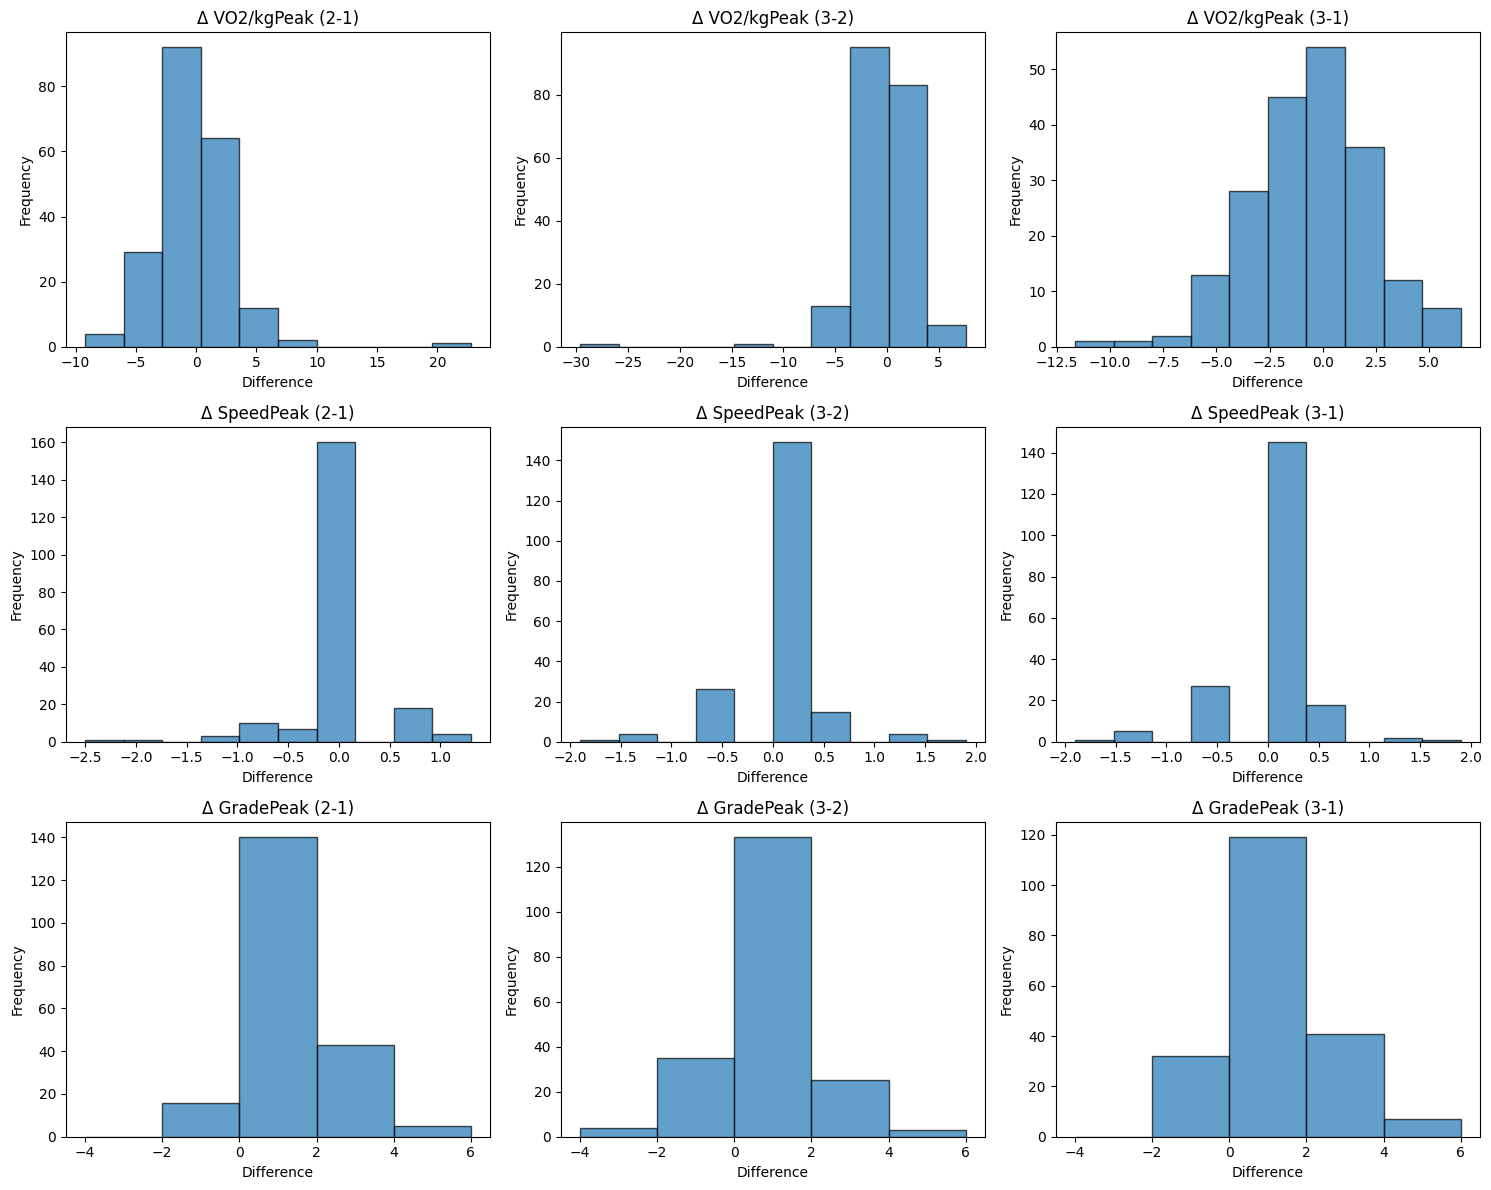

,VO2_peak_Diff_2-1,VO2_peak_Diff_3-2,VO2_peak_Diff_3-1
count,204.000000,200.000000,199.000000
mean,2.731115,-6.420298,-10.641635
std,377.870815,331.889921,271.181096
min,-3694.199631,-837.648874,-719.713865
25%,-110.041435,-184.128581,-171.172503
50%,41.206045,-35.562844,0.152961
75%,182.184899,145.641946,168.030176
max,655.620676,2974.485765,692.753061


In [68]:
# Pivot to structure data for difference calculations
df_pivot = VO2_outcome_df.pivot(index="ID", columns="Visit Number", values=["VO2/kgPeak", "SpeedPeak", "GradePeak", 'VO2_peak'])
df_pivot.columns = [f"{col[0]}_Visit{col[1]}" for col in df_pivot.columns]

# Compute differences between all visit pairs
df_pivot["VO2/kgPeak_Diff_2-1"] = df_pivot["VO2/kgPeak_Visit2"] - df_pivot["VO2/kgPeak_Visit1"]
df_pivot["VO2/kgPeak_Diff_3-2"] = df_pivot["VO2/kgPeak_Visit3"] - df_pivot["VO2/kgPeak_Visit2"]
df_pivot["VO2/kgPeak_Diff_3-1"] = df_pivot["VO2/kgPeak_Visit3"] - df_pivot["VO2/kgPeak_Visit1"]

df_pivot["SpeedPeak_Diff_2-1"] = df_pivot["SpeedPeak_Visit2"] - df_pivot["SpeedPeak_Visit1"]
df_pivot["SpeedPeak_Diff_3-2"] = df_pivot["SpeedPeak_Visit3"] - df_pivot["SpeedPeak_Visit2"]
df_pivot["SpeedPeak_Diff_3-1"] = df_pivot["SpeedPeak_Visit3"] - df_pivot["SpeedPeak_Visit1"]

df_pivot["GradePeak_Diff_2-1"] = df_pivot["GradePeak_Visit2"] - df_pivot["GradePeak_Visit1"]
df_pivot["GradePeak_Diff_3-2"] = df_pivot["GradePeak_Visit3"] - df_pivot["GradePeak_Visit2"]
df_pivot["GradePeak_Diff_3-1"] = df_pivot["GradePeak_Visit3"] - df_pivot["GradePeak_Visit1"]

df_pivot["VO2_peak_Diff_2-1"] = df_pivot["VO2_peak_Visit2"] - df_pivot["VO2_peak_Visit1"]
df_pivot["VO2_peak_Diff_3-2"] = df_pivot["VO2_peak_Visit3"] - df_pivot["VO2_peak_Visit2"]
df_pivot["VO2_peak_Diff_3-1"] = df_pivot["VO2_peak_Visit3"] - df_pivot["VO2_peak_Visit1"]

# Plot histograms
grade_bins = sorted(df_pivot[[f"GradePeak_Diff_{x}" for x in ["2-1", "3-2", "3-1"]]].stack().unique())
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
diff_columns = ["VO2/kgPeak_Diff_2-1", "VO2/kgPeak_Diff_3-2", "VO2/kgPeak_Diff_3-1",
                "SpeedPeak_Diff_2-1", "SpeedPeak_Diff_3-2", "SpeedPeak_Diff_3-1",
                "GradePeak_Diff_2-1", "GradePeak_Diff_3-2", "GradePeak_Diff_3-1",
                "VO2_peak_Diff_2-1", "VO2_peak_Diff_3-2", "VO2_peak_Diff_3-1"]
titles = ["Δ VO2/kgPeak (2-1)", "Δ VO2/kgPeak (3-2)", "Δ VO2/kgPeak (3-1)",
          "Δ SpeedPeak (2-1)", "Δ SpeedPeak (3-2)", "Δ SpeedPeak (3-1)",
          "Δ GradePeak (2-1)", "Δ GradePeak (3-2)", "Δ GradePeak (3-1)",
          "Δ VO2 Peak (2-1)", "Δ VO2 Peak (3-2)", "Δ VO2 Peak (3-1)"]

for ax, col, title in zip(axes.flatten(), diff_columns, titles):
    if "Grade" in col:
        # For GradePeak, set bins to be the unique values
        bins = grade_bins
    else:
        bins = 10
    ax.hist(df_pivot[col].dropna(), bins=bins, edgecolor='black', alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel("Difference")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()
df_pivot[['VO2_peak_Diff_2-1', 'VO2_peak_Diff_3-2', 'VO2_peak_Diff_3-1']].describe()

In [117]:
columns = ["Start Time",
        "End Time",
        "VO2 (mL/min)",
        "VO2 (mL/min/kg)",
        "Velocity (km/h)",
        "Grade (%)",
        "Stage (#)",
        "RPE (#)",
        "HR (bpm)",
        "Lactate (mmol/L)",
        "RQ",
        "True VO2max? T/F",
        "Reach Steady State? T/F",
        "O2 variance"]
dtypes = {
    "True VO2max? T/F": "boolean",
    "Reach Steady State? T/F": "boolean"
}
def is_steady_state(O2_series):
    variance = O2_series.std()/O2_series.mean()
    threshold = 0.02  
    return variance < threshold
    

def get_stage_metrics(stage_df, summary_df,window_size_seconds):
    if stage_df.empty:
        print(f"Warning: Empty DataFrame for stage {stage_df.name}")
        return
    
    #Get start and end times of analysis window
    filtered_times = stage_df[stage_df['t'] <= stage_df['t'].values[-1] - pd.Timedelta(seconds=window_size_seconds)]['t']
    if not filtered_times.empty:
        start_time = filtered_times.values[-1]
    else:
        return #less than window size data in stage to analyze
    
    #Create row for stage in summary_df
    summary_df.loc[stage_df.name]=np.nan
    #print(f"Stage {stage_df.name}: Filtered times count: {len(filtered_times)}")
    #print(f"Last available time: {stage_df['t'].values[-1]}")   
    #print(f"Threshold time: {stage_df['t'].values[-1] - pd.Timedelta(seconds=window_size_seconds)}")

    summary_df.loc[stage_df.name, 'Start Time'] = str(pd.to_datetime(start_time).strftime('%H:%M:%S'))
    summary_df.loc[stage_df.name, 'End Time'] = str(pd.to_datetime(stage_df['t'].values[-1]).strftime('%H:%M:%S'))
    summary_df.loc[stage_df.name, 'Velocity (km/h)'] = stage_df['Speed'].values[0]
    summary_df.loc[stage_df.name, 'Grade (%)'] = stage_df['Grade'].values[0]
    summary_df.loc[stage_df.name, 'Stage (#)'] = stage_df['Stage'].values[0]
    
    #Use last RPE rating and last recorded lactate value
    if isinstance(stage_df['Dyspnea'].values[-1], str): 
        summary_df.loc[stage_df.name, 'RPE (#)'] = int(stage_df['Dyspnea'].values[-1].split("_")[-1])
    else:
        summary_df.loc[stage_df.name, 'RPE (#)'] = stage_df['Dyspnea'].values[-1]
    summary_df.loc[stage_df.name, 'Lactate (mmol/L)'] = stage_df['_49'].values[-1]
    
    #Average values over the last 50 seconds (or designated window size)
    summary_df.loc[stage_df.name, 'VO2 (mL/min)'] = stage_df[stage_df['t'] >= start_time]['VO2'].mean()
    summary_df.loc[stage_df.name, 'VO2 (mL/min/kg)'] = stage_df[stage_df['t'] >= start_time]['_16'].mean()
    summary_df.loc[stage_df.name, 'HR (bpm)'] = stage_df[stage_df['t'] >= start_time]['HR'].mean()
    summary_df.loc[stage_df.name, 'RQ'] = stage_df[stage_df['t'] >= start_time]['RQ'].mean()

    #True Vo2max if RQ is above threshold
    summary_df.loc[stage_df.name, 'True VO2max? T/F'] = summary_df.loc[stage_df.name, 'RQ'] > rq_threshold
    summary_df.loc[stage_df.name, 'Reach Steady State? T/F'] = is_steady_state(stage_df[stage_df['t'] >= start_time]['VO2'])
    summary_df.loc[stage_df.name, 'O2 variance'] = stage_df[stage_df['t'] >= start_time]['VO2'].var()

def create_test_summary(test_df,window_size_seconds):
    df = pd.DataFrame(columns=columns).astype(dtypes)
    test_df.groupby('Stage').apply(get_stage_metrics, df, window_size_seconds)
    return df


In [119]:

#Create nested dictionary to store test summaries
#Outer dictionary key is the participant ID
#Inner dictionary key is the visit number
#Inner dictionary value is the test summary DataFrame (grouped by stage)
def create_summaries_dfs(window_size_seconds = 30):
    summaries = {}
    for participant_id, df in participant_df.items():
        id = participant_id.split('_')[0]  #Extract the first part of the participant ID (id)
        if id not in summaries:
            summaries[id] = {}
            summaries[id][1] = create_test_summary(df,window_size_seconds)
        else:
            next_visit = max(summaries[id].keys()) + 1
            summaries[id][next_visit] = create_test_summary(df,window_size_seconds)

    return summaries

summaries = create_summaries_dfs()
summaries['TR000103'][2]

/var/folders/4v/55nqzrk56yz5gzf4ld7y124h0000gn/T/ipykernel_75692/2170953043.py:43: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '00:07:31' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  summary_df.loc[stage_df.name, 'Start Time'] = str(pd.to_datetime(start_time).strftime('%H:%M:%S'))
/var/folders/4v/55nqzrk56yz5gzf4ld7y124h0000gn/T/ipykernel_75692/2170953043.py:44: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '00:08:01' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  summary_df.loc[stage_df.name, 'End Time'] = str(pd.to_datetime(stage_df['t'].values[-1]).strftime('%H:%M:%S'))
/var/folders/4v/55nqzrk56yz5gzf4ld7y124h0000gn/T/ipykernel_75692/2170953043.py:63: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise

,Start Time,End Time,VO2 (mL/min),VO2 (mL/min/kg),Velocity (km/h),Grade (%),Stage (#),RPE (#),HR (bpm),Lactate (mmol/L),RQ,True VO2max? T/F,Reach Steady State? T/F,O2 variance
1.0,00:09:32,00:10:02,2313.234343,32.046667,7.4,0.0,1.0,NaN,139.333333,58.1,0.828667,False,False,30518.475740
2.0,00:12:32,00:13:02,2492.528345,31.993750,8.0,0.0,2.0,12.0,147.531250,34.8,0.875625,False,False,14236.816752
3.0,00:15:32,00:16:02,2726.265675,33.036364,8.6,0.0,3.0,13.0,157.666667,13.4,0.913333,False,False,75739.328282
4.0,00:18:32,00:19:02,2866.293922,34.173529,9.3,0.0,4.0,14.0,165.500000,8.9,0.952647,False,False,14963.797199
5.0,00:20:16,00:20:46,2956.497797,34.242857,9.9,0.0,5.0,16.0,169.000000,7.4,0.971429,False,False,20879.912782


In [128]:
#Testing Steady State Column
import warnings
warnings.simplefilter(action='ignore')
def find_best_window_size():
    for i in range(10,35):
        summaries = create_summaries_dfs(i)
        sum_true = 0
        sum_df_true = 0
        for key in summaries.keys():
            for key2 in summaries[key].keys():
                #print(f"{i},{key},{key2},{(summaries[key][key2]['Reach Steady State? T/F'] == True).sum() > 0}")
                sum_true += (summaries[key][key2]['Reach Steady State? T/F'] == True).sum()
                if (summaries[key][key2]['Reach Steady State? T/F'] == True).sum() > 0:
                    sum_df_true += 1
        
        print(f"window size = {i},total true values = {sum_true},total true dfs = {sum_df_true}")

#(summaries['TR000103'][2]['Reach Steady State? T/F'] == True).sum()
find_best_window_size()

window size = 10,total true values = 9,total true dfs = 7
window size = 11,total true values = 10,total true dfs = 8
window size = 12,total true values = 8,total true dfs = 7
window size = 13,total true values = 8,total true dfs = 7
window size = 14,total true values = 7,total true dfs = 6
window size = 15,total true values = 6,total true dfs = 5
window size = 16,total true values = 6,total true dfs = 5
window size = 17,total true values = 5,total true dfs = 4
window size = 18,total true values = 5,total true dfs = 4
window size = 19,total true values = 4,total true dfs = 4
window size = 20,total true values = 5,total true dfs = 4
window size = 21,total true values = 5,total true dfs = 4
window size = 22,total true values = 3,total true dfs = 3
window size = 23,total true values = 4,total true dfs = 3
window size = 24,total true values = 4,total true dfs = 3
window size = 25,total true values = 4,total true dfs = 3
window size = 26,total true values = 4,total true dfs = 3
window size =

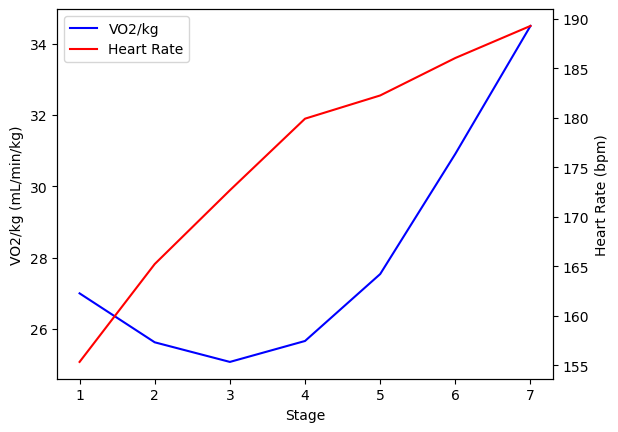

In [13]:
import matplotlib.pyplot as plt

data = summaries['TR000100'][1]

# Create the twin axis plot
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

# Plot VO2/kg on the first axis
ax1.plot(data['Stage (#)'], data['VO2 (mL/min/kg)'], 'b-', label='VO2/kg')
ax1.set_xlabel('Stage')
ax1.set_ylabel('VO2/kg (mL/min/kg)')

# Plot heart rate on the second axis
ax2.plot(data['Stage (#)'], data['HR (bpm)'], 'r-', label='Heart Rate')
ax2.set_ylabel('Heart Rate (bpm)')

# Set the legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

# Show the plot
plt.show()






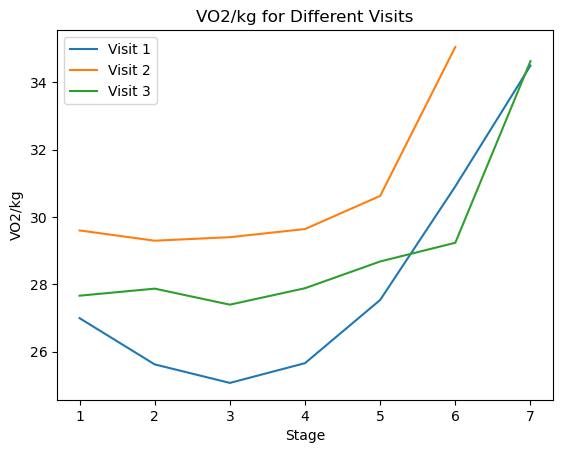

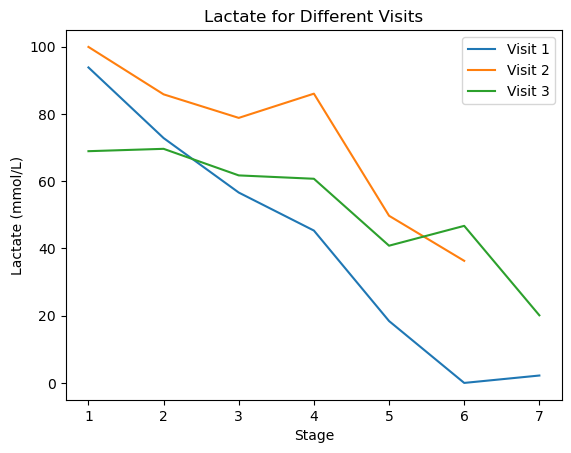

In [14]:
import matplotlib.pyplot as plt

# Get the summary tables for TR000100
summary_1 = summaries['TR000100'][1]
summary_2 = summaries['TR000100'][2]
summary_3 = summaries['TR000100'][3]

# Plot VO2/kg for each visit
plt.plot(summary_1['Stage (#)'], summary_1['VO2 (mL/min/kg)'], label='Visit 1')
plt.plot(summary_2['Stage (#)'], summary_2['VO2 (mL/min/kg)'], label='Visit 2')
plt.plot(summary_3['Stage (#)'], summary_3['VO2 (mL/min/kg)'], label='Visit 3')

# Set plot title and labels
plt.title('VO2/kg for Different Visits')
plt.xlabel('Stage')
plt.ylabel('VO2/kg')

# Add legend
plt.legend()

# Show the plot
plt.show()
plt.plot(summary_1['Stage (#)'], summary_1['Lactate (mmol/L)'], label='Visit 1')
plt.plot(summary_2['Stage (#)'], summary_2['Lactate (mmol/L)'], label='Visit 2')
plt.plot(summary_3['Stage (#)'], summary_3['Lactate (mmol/L)'], label='Visit 3')

# Set plot title and labels
plt.title('Lactate for Different Visits')
plt.xlabel('Stage')
plt.ylabel('Lactate (mmol/L)')

# Add legend
plt.legend()

# Show the plot
plt.show()



In [15]:
# Specify the time after which you want to get the first value
target_time = pd.to_datetime('1900-01-01 00:22:30')

# Filter the DataFrame based on the time condition and select the first value
first_value = VO2_outcome_df.loc[VO2_outcome_df['VO2Peak start time- local'] > target_time, 'VO2_peak'].iloc[0]

# Print the first value
print(first_value)


3453.436232052


In [16]:
def get_VO2_kg_peak(df_dictionary, result_df):
    id_list = list(result_df.index)
    for id in id_list:
        df = df_dictionary[id]
        
        # Convert 'timestamp' to seconds elapsed
        df['seconds_elapsed'] = df['t'].apply(
            lambda x: int(x.split(':')[0]) * 3600 + int(x.split(':')[1]) * 60 + int(x.split(':')[2])
        )
        
        # Initialize variables for tracking VO2_peak and VO2/kgPeak
        peak_value = float('-inf')
        peak_start_time = None
        peak_end_time = None
        kg_peak_value = None

        # Iterate through each row to compute the rolling mean based on a 30-second window
        for i, current_row in df.iterrows():
            current_time = current_row['seconds_elapsed']
            window_end = current_time
            window_start = current_time - 30
            
            # Select rows within the 30-second window
            window_data_VO2 = df[(df['seconds_elapsed'] >= window_start) & (df['seconds_elapsed'] <= window_end)]['VO2']
            rolling_mean_VO2 = window_data_VO2.mean()

            # Update the peak value and corresponding time window
            if rolling_mean_VO2 > peak_value:
                peak_value = rolling_mean_VO2
                peak_start_time = window_start
                peak_end_time = window_end

                # Find the rolling mean of the _16 column for the same interval
                window_data_16 = df[(df['seconds_elapsed'] >= window_start) & (df['seconds_elapsed'] <= window_end)]['_16']
                kg_peak_value = window_data_16.mean()

        # Convert seconds back to HH:MM:SS format
        def seconds_to_hhmmss(seconds):
            hours = seconds // 3600
            minutes = (seconds % 3600) // 60
            seconds = seconds % 60
            return f"{hours:02}:{minutes:02}:{seconds:02}"

        # Record results in the result DataFrame
        result_df.loc[id, 'VO2_peak'] = peak_value
        result_df.loc[id, 'VO2Peak start time- global'] = seconds_to_hhmmss(peak_start_time)
        result_df.loc[id, 'VO2Peak end time- global'] = seconds_to_hhmmss(peak_end_time)
        result_df.loc[id, 'VO2/kgPeak'] = kg_peak_value
    return result_df

VO2_outcome_df = get_VO2_kg_peak(participant_df, VO2_outcome_df)
VO2_outcome_df
   

AttributeError: 'Timestamp' object has no attribute 'split'

Index(['Index', 'participant_ID', 'visit_date', '_3', 't', 'Rf', 'VT', 'VE',
       'IV', 'VO2', 'VCO2', 'RQ', 'O2exp', 'CO2exp', '_14', '_15', '_16',
       'METS', 'HR', '_19', 'FeO2', 'FeCO2', 'FetO2', 'FetCO2', 'FiO2',
       'FiCO2', 'PeO2', 'PeCO2', 'PetO2', 'PetCO2', 'SpO2', 'Grade', 'Speed',
       'Phase', 'Marker', '_35', '_36', '_37', 'PB', 'EEkc', 'EEh', 'EEm',
       'EEtot', 'EEkg', 'PRO', 'Fat', 'CHO', '_47', '_48', '_49', 'npRQ',
       '_51', '_52', '_53', '_54', '_55', '_56', '_57', '_58', '_59', '_60',
       '_61', '_62', '_63', '_64', '_65', '_66', '_67', '_68', '_69', '_70',
       '_71', '_72', '_73', '_74', '_75', '_76', 'Ti', 'Te', 'Ttot', '_80',
       '_81', 'LogVE', '_83', '_84', '_85', '_86', '_87', 'BR', '_89', 'HRR',
       'PaCO2_e', 'Dyspnea', '_93', '_94'],
      dtype='object')

In [ ]:
#Create Result Dataframes
def create_results_dictionary(parent_df):
    """
    Creates a nested dictionary to store participant test results in a structured format.

    Args:
        parent_df (pd.DataFrame): DataFrame containing participant IDs and visit dates.

    Returns:
        dict: A dictionary where keys are unique participant-visit combinations and 
              values are empty pandas DataFrames with predefined columns and rows.
    """

    # Initialize an empty dictionary to store participants' visit data
    participant_registry = dict()

     # First loop: Initialize an empty dictionary for each participant ID
    for row in parent_df.itertuples():
        participant_registry[row.participant_ID] = dict()
    
     # Second loop: Initialize an empty list for each visit date within each participant's dictionary
    for row in parent_df.itertuples():
        participant_registry[row.participant_ID][row.visit_date] = []
    
     # Dictionary to store the final DataFrame results for each participant visit
    participant_result_df = dict()

     # Define the column names for the DataFrame (representing different exercise stages)
    columns = ["V02max", "LT1", "LT2", "VT1", "VT2", "Stage 1", "Stage 2", "Stage 3", "... Stage X"]

     # Define the row labels (representing different physiological metrics measured during testing)
    rows = [
        "VO2 (mL/min/kg)",
        "Velocity (km/h)",
        "Grade (%)",
        "Stage (#)",
        "RPE (#)",
        "HR (bpm)",
        "Lactate (mmol/L)",
        "RQ",
        "True VO2max? Y/N",
        "Reach Steady State?",
    ]

     # Loop through each participant and visit date to initialize an empty DataFrame for results
    for participant_id, participant_data in participant_registry.items():
        for visit_date in participant_data.keys():
            # Create an empty DataFrame with the predefined structure and store it in the dictionary
            participant_result_df[f'{participant_id}_{visit_date}'] = pd.DataFrame(columns=columns, index=rows)
    print(participant_df.keys())
    return participant_result_df

participant_result_df = create_results_dictionary(big_frame)
participant_result_df['TR000105_20220207']


dict_keys(['TR000105_20220207', 'TR000105_20220517', 'TR000105_20220920', 'TR000106_20220420', 'TR000106_20220208', 'TR000106_20220823', 'TR000102_20220204', 'TR000102_20220401', 'TR000102_20220630', 'TR000100_20220623', 'TR000100_20220331', 'TR000100_20220203', 'TR000104_20220627', 'TR000104_20220207', 'TR000104_20220314', 'TR000109_20220209', 'TR000109_20220824', 'TR000109_20220518', 'TR000107_20220519', 'TR000107_20220208', 'TR000107_20220805', 'TR000103_20220401', 'TR000103_20220204', 'TR000103_20220706', 'TR000101_20220203', 'TR000101_20220630', 'TR000101_20220331', 'TR000110_20220210', 'TR000110_20220428', 'TR000110_20220901', 'TR000108_20220209'])


,V02max,LT1,LT2,VT1,VT2,Stage 1,Stage 2,Stage 3,... Stage X
VO2 (mL/min/kg),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Velocity (km/h),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Grade (%),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Stage (#),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RPE (#),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HR (bpm),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lactate (mmol/L),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RQ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
True VO2max? Y/N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Reach Steady State?,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
